# Task 1: News Topic Classifier Using BERT

## Problem Statement & Objective
With the immense volume of news articles published online every day, platforms need robust, automated categorization pipelines to route content cleanly for search and recommendation engines.

**Objective:** My goal in this task is to fine-tune a pre-trained transformer model (`bert-base-uncased`) to automatically and accurately classify news headlines and short text snippets into four distinct topic categories: World, Sports, Business, and Sci/Tech.

# Dependencies

In [1]:
# Install required libraries if running in a fresh environment
!pip install transformers datasets evaluate accelerate gradio scikit-learn torch matplotlib seaborn

import torch
import evaluate
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00


## Dataset Loading & Preprocessing
I am using the **AG News Dataset**. Instead of managing local file downloads manually, I leverage the Hugging Face `datasets` library to directly load and cache the corpus. I initialize the standard `bert-base-uncased` tokenizer and apply a mapping function to convert raw text strings into uniform arrays of padded and truncated tokens.

In [2]:
# Loading the AG News dataset natively via Hugging Face datasets
print("Loading the AG News dataset...")
dataset = load_dataset("ag_news")

# Initializing the standard BERT tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Defining a preprocessing function to tokenize text with dynamic padding and truncation
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Applying tokenization across all dataset splits...")
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# To ensure smooth and rapid training passes on standard GPU hardware during my development phase,
# I am selecting a representative subset. (I can remove `.select()` to train on the entire dataset).
train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(6000))
eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(1500))

Loading the AG News dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Applying tokenization across all dataset splits...


Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

## Model Development & Training
I load the pre-trained sequence classification weights for BERT base, attaching a custom classification head mapped to my 4 target labels. I configure the Hugging Face `Trainer` API with tailored `TrainingArguments` to manage optimization, evaluation loops, and checkpointing cleanly without manual boilerplates.

In [3]:
# Mapping the integer IDs to their respective AG News target classes
id2label = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
label2id = {v: k for k, v in id2label.items()}

# Loading the pre-trained BERT base model configured specifically for 4 output classes
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

# Loading the exact evaluation metrics specified in the task checklist
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

# Creating a custom metrics calculation function for the Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1": f1}

# Configuring my hyperparameters and training arguments
training_args = TrainingArguments(
    output_dir="./news_bert_artifacts",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none" # Ensuring terminal output remains uncluttered
)

# Initializing the operational Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

print("Executing BERT fine-tuning process...")
trainer.train()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Executing BERT fine-tuning process...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.280572,0.289101,0.894000,0.893924
2,0.228782,0.292487,0.916667,0.916727
3,0.117721,0.313712,0.914000,0.914195


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1125, training_loss=0.25095456822713214, metrics={'train_runtime': 463.7692, 'train_samples_per_second': 38.812, 'train_steps_per_second': 2.426, 'total_flos': 1184021010432000.0, 'train_loss': 0.25095456822713214, 'epoch': 3.0})

## Evaluation with Relevant Metrics
I evaluate the fine-tuned model against my unseen test split using **Accuracy** and **F1-score** to ensure balanced, unbiased classification performance across all topic categories.

In [4]:
# Triggering the final evaluation scoring pass
metrics = trainer.evaluate()

print("\n==========================================")
print("Final Evaluation Metrics on Test Split:")
print("==========================================")
print(f"Accuracy:  {metrics['eval_accuracy']:.4f}")
print(f"F1-Score:  {metrics['eval_f1']:.4f}")

# Saving my final production-ready model weights and tokenizer locally
model.save_pretrained("./fine_tuned_bert_news")
tokenizer.save_pretrained("./fine_tuned_bert_news")
print("\nModel successfully saved to './fine_tuned_bert_news'")


Final Evaluation Metrics on Test Split:
Accuracy:  0.8940
F1-Score:  0.8939


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model successfully saved to './fine_tuned_bert_news'


## Visualizations
To evaluate exactly where my model might be misinterpreting context, I generate a **Confusion Matrix** comparing the true labels against my BERT model's raw categorical predictions.

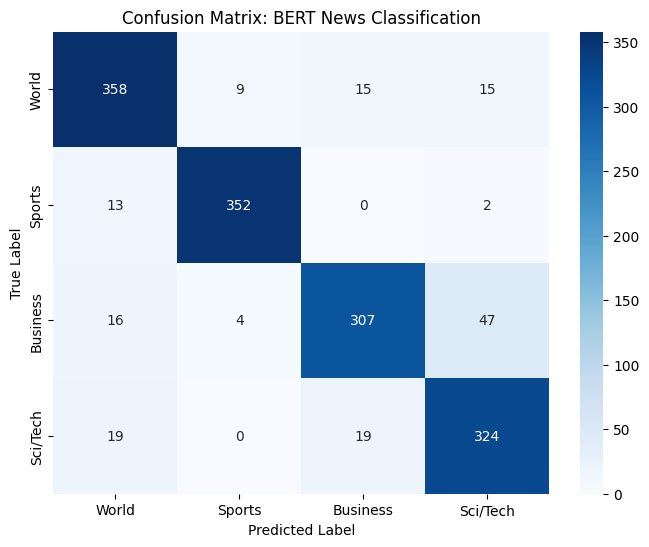

In [6]:
from sklearn.metrics import confusion_matrix
# Generating raw inference predictions across the evaluation partition
predictions_output = trainer.predict(eval_dataset)
y_preds = np.argmax(predictions_output.predictions, axis=-1)
y_true = eval_dataset["label"]

# Computing the discrete confusion matrix
cm = confusion_matrix(y_true, y_preds)
labels = [id2label[i] for i in range(4)]

# Rendering the output cleanly using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: BERT News Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()